# Pattern Recognition 1 - Expert System

**Objectives**

* Create a working image analysis and pattern recognition pipeline
* Object labelisation and feature extraction
* Creating an Expert System for Optical Character Recognition (OCR)

**Libraries needed for this lab**

* Numpy
* Matplotlib
* Scikit-image

(all included in the Anaconda distribution)

## Object detection

Given the following image :

(851, 1068) uint8


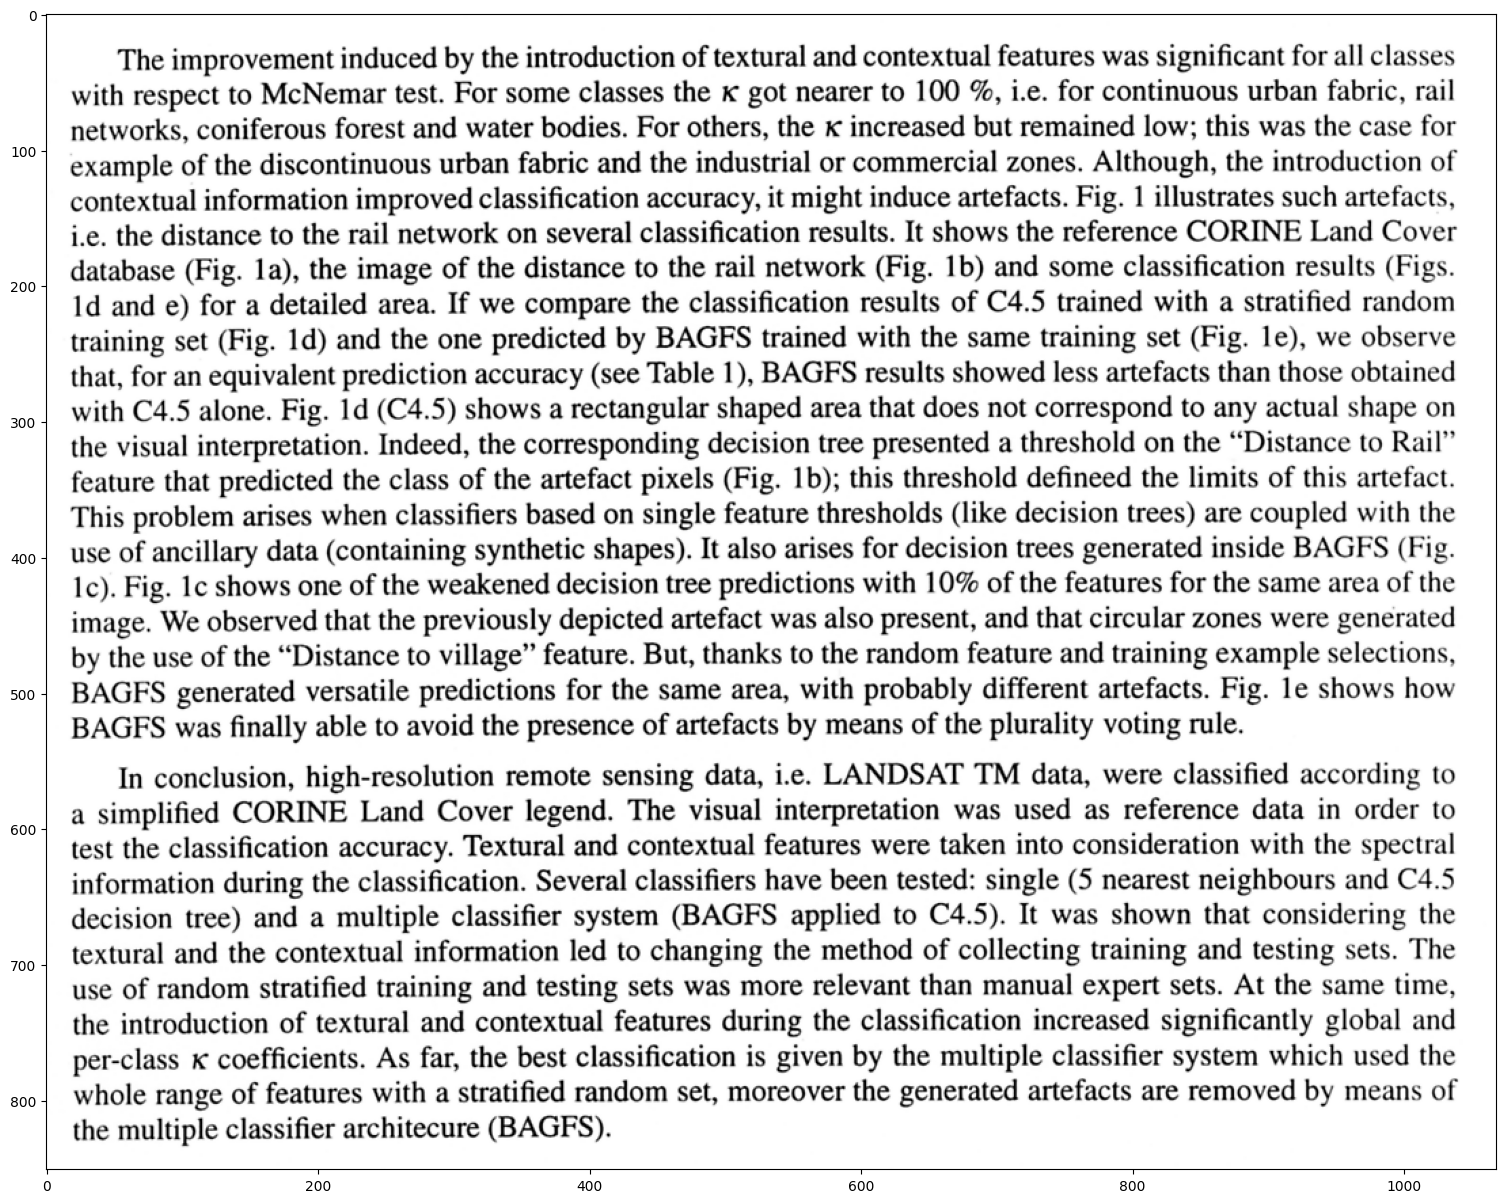

In [3]:
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread
%matplotlib inline

im = imread('../data/doc1.png')
print(im.shape, im.dtype)

plt.figure(figsize=(20,15))
plt.imshow(im, cmap=plt.cm.gray)
plt.show()

* **Segment** the image to isolate the text from the background
* **Label individual characters** and **extract** the centroid position, the bounding box, and useful features for each character.

Useful documentation: [`skimage.measure`](http://scikit-image.org/docs/dev/api/skimage.measure.html) module.

0
255


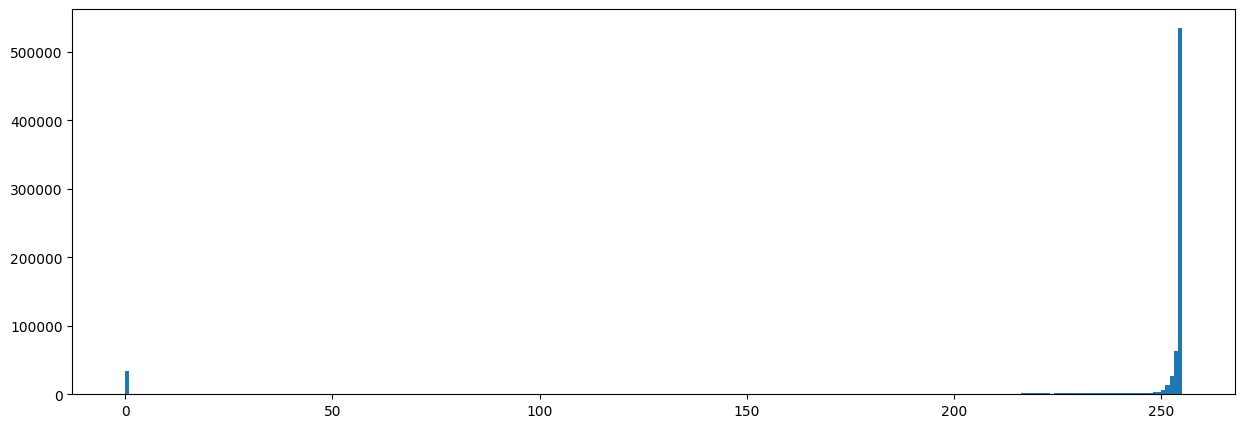

In [7]:
from skimage.measure import label, centroid

print(im.min())
print(im.max())
plt.figure(figsize=(15,5))
plt.hist(im.flatten(), bins=256)
plt.show()


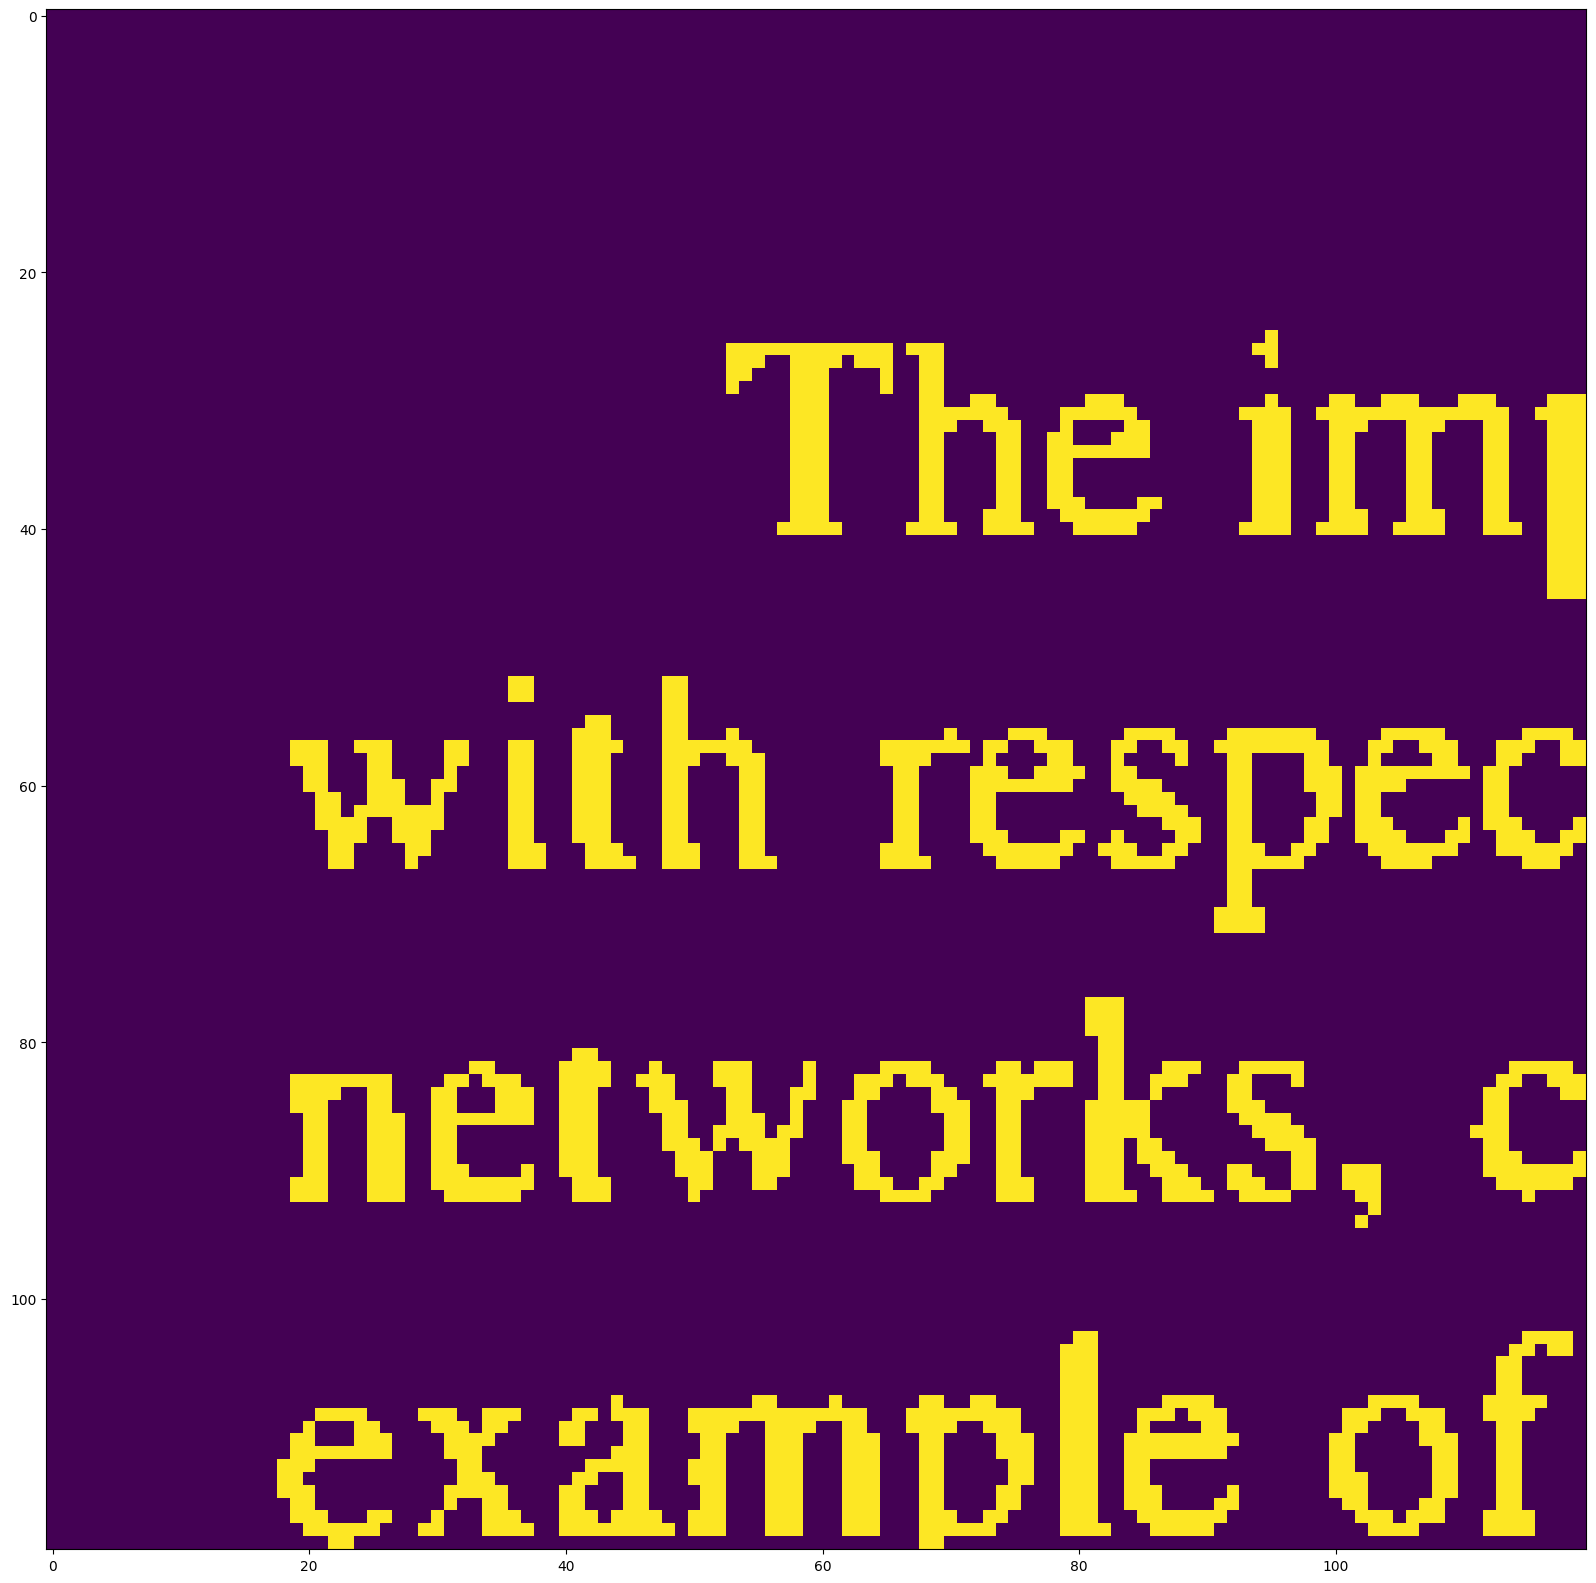

In [4]:
segmented = im<150
plt.figure(figsize=(20,20))
plt.imshow(segmented[:120,:120])
plt.show()

(851, 1068) int32
3066


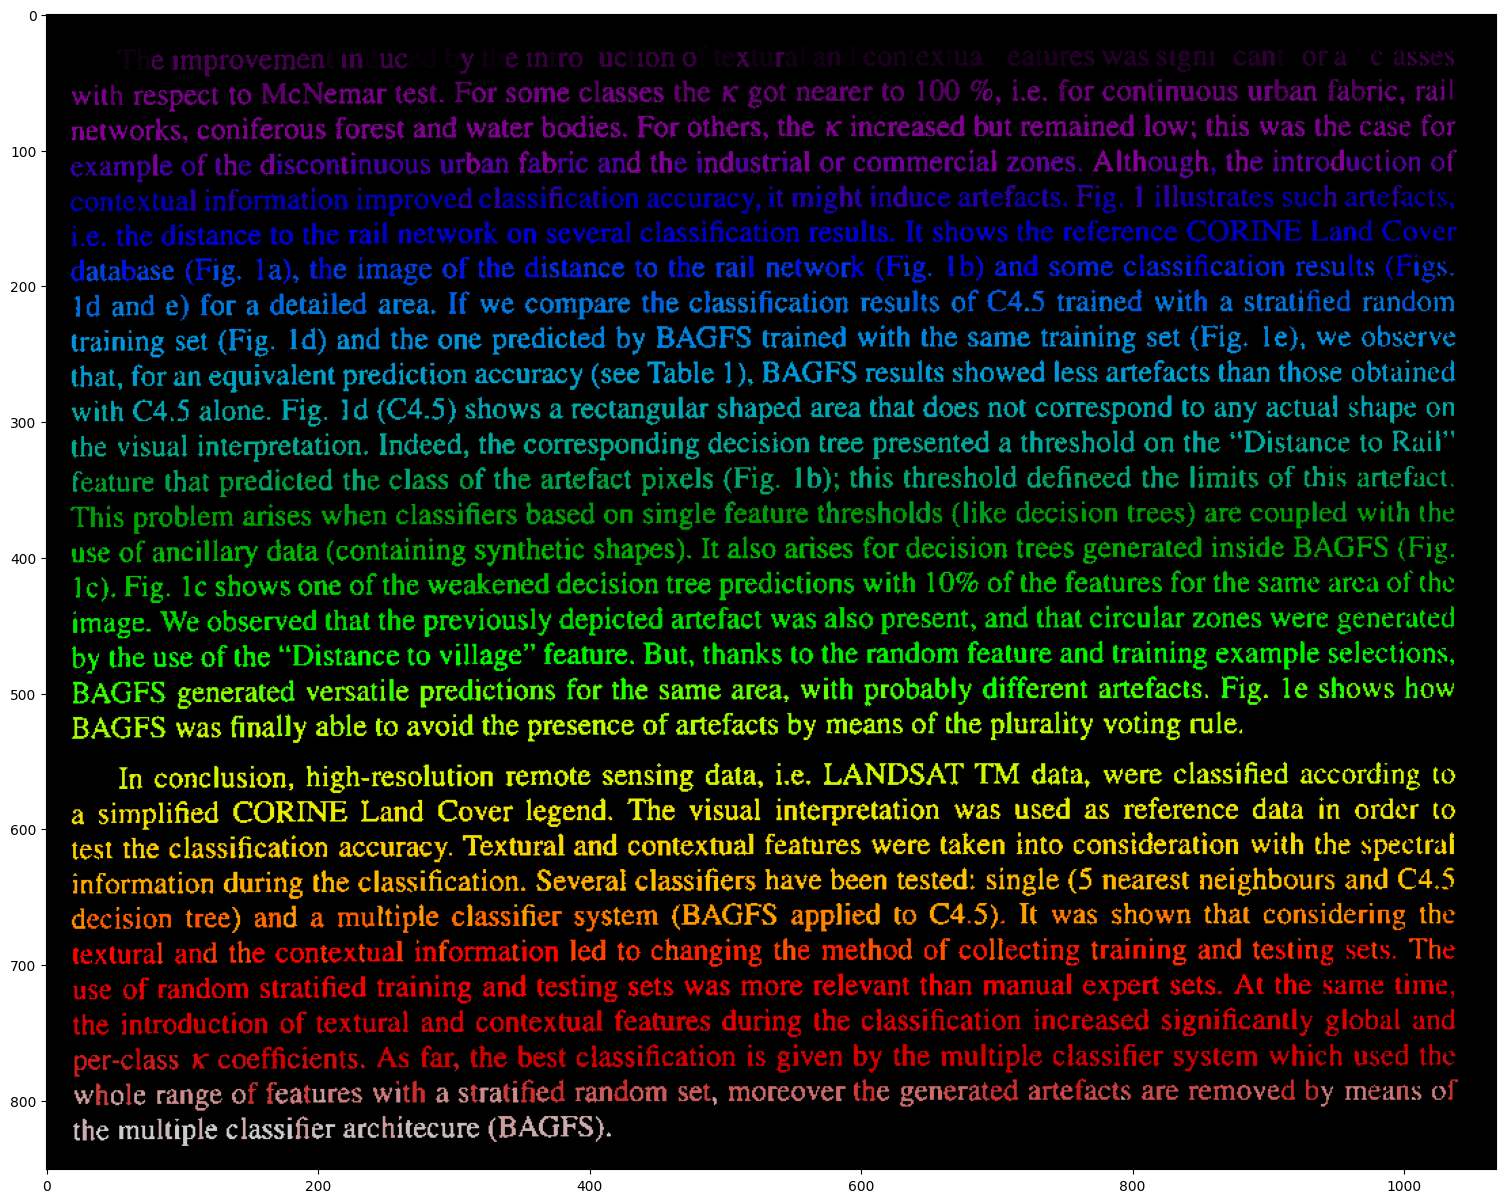

In [8]:
label_im,num = label(segmented,background=0, connectivity=2, return_num=True)
print(label_im.shape, label_im.dtype)
print(num)
plt.figure(figsize=(20,15))
plt.imshow(label_im, cmap=plt.cm.nipy_spectral)
plt.show()


Note that the label are assigned in order as the alorithm go through the image and is is not speciallcy in the lecture order. We can extract the information about the order of each label in order to group them based on their position on the vertical axis

In [9]:
from skimage.measure import regionprops
object_properties = regionprops(label_im)
for obj in object_properties: #obj is a region with the same label
    print(obj['centroid'], obj['bbox'])
    break

(np.float64(30.142857142857142), np.float64(692.5142857142857)) (22, 691, 38, 695)


## Line detection and letter ordering

* Find the labels (objects) that belong to each text line
* Order each character in a text line from left to right

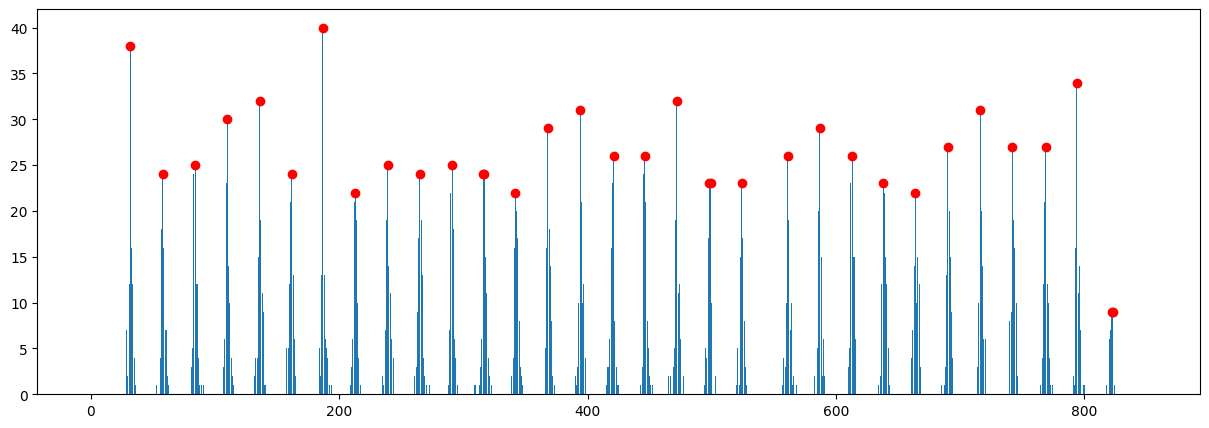

In [10]:
centroids_y= np.zeros((im.shape[0]))
for obj in object_properties:
    if obj.area <10:
        continue #passe à objet suivant quand aire < 10 , pour enelever par exemple dots of i and j
    centroids_y[int(obj['centroid'][0])] += 1 #count how many centroids are in each row , ['centroid'][0] position verticale, donc on ajoute 1 a la ligne corresp a cette position verticale
maxima = []
for y in range(3,im.shape[0]-3):
    if centroids_y[y] == centroids_y[y-3:y+3].max() and centroids_y[y]>5: #si le nombre de centroids dans la ligne y est égal au maximum des lignes y-3 à y+3 et que ce nombre est supérieur à 5
        maxima.append(y) #ligne qui contient un maximum local de centroids


plt.figure(figsize=(15,5))
plt.bar(range(im.shape[0]),centroids_y) #number of centroids (label) in each row
for m in maxima:
    plt.plot(m,centroids_y[m],'ro') #plot in red the local maxima
plt.show()



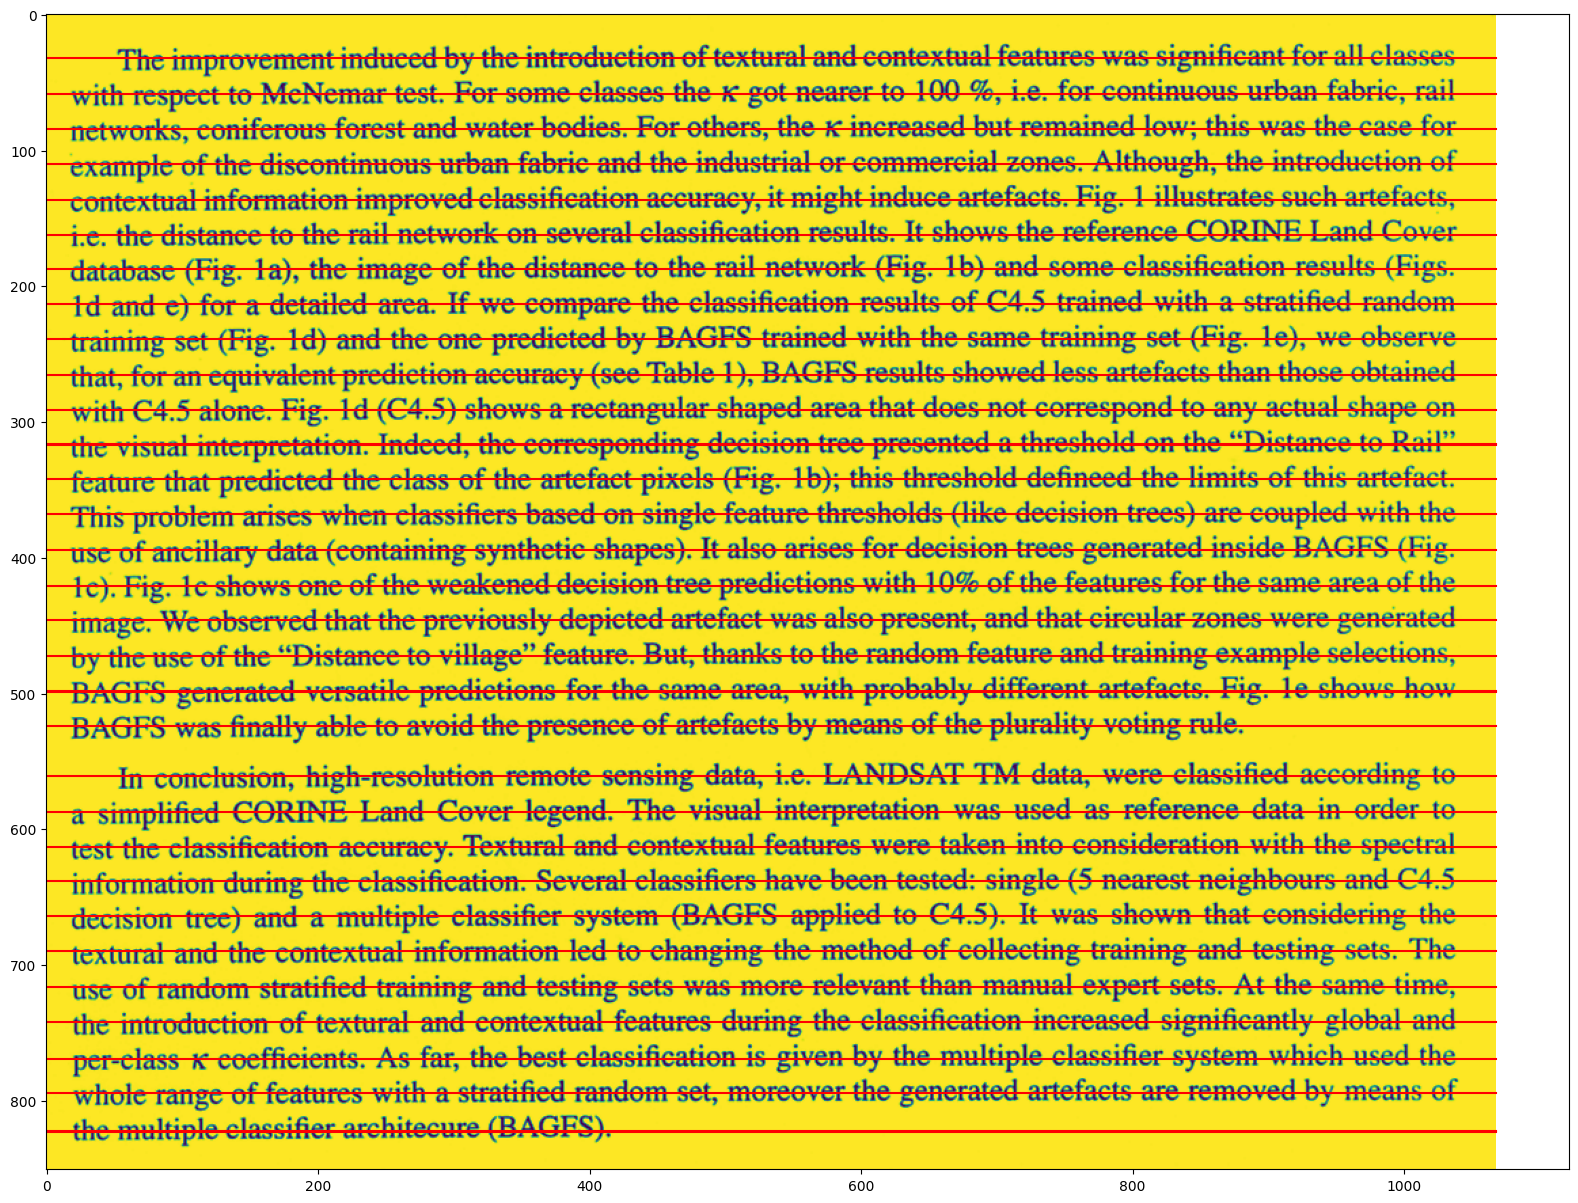

In [11]:
plt.figure(figsize=(20,15))
plt.imshow(im)
for m in maxima: 
    plt.plot([0,im.shape[1]],[m,m],'r-') #plot in red the local maxima as horizontal lines



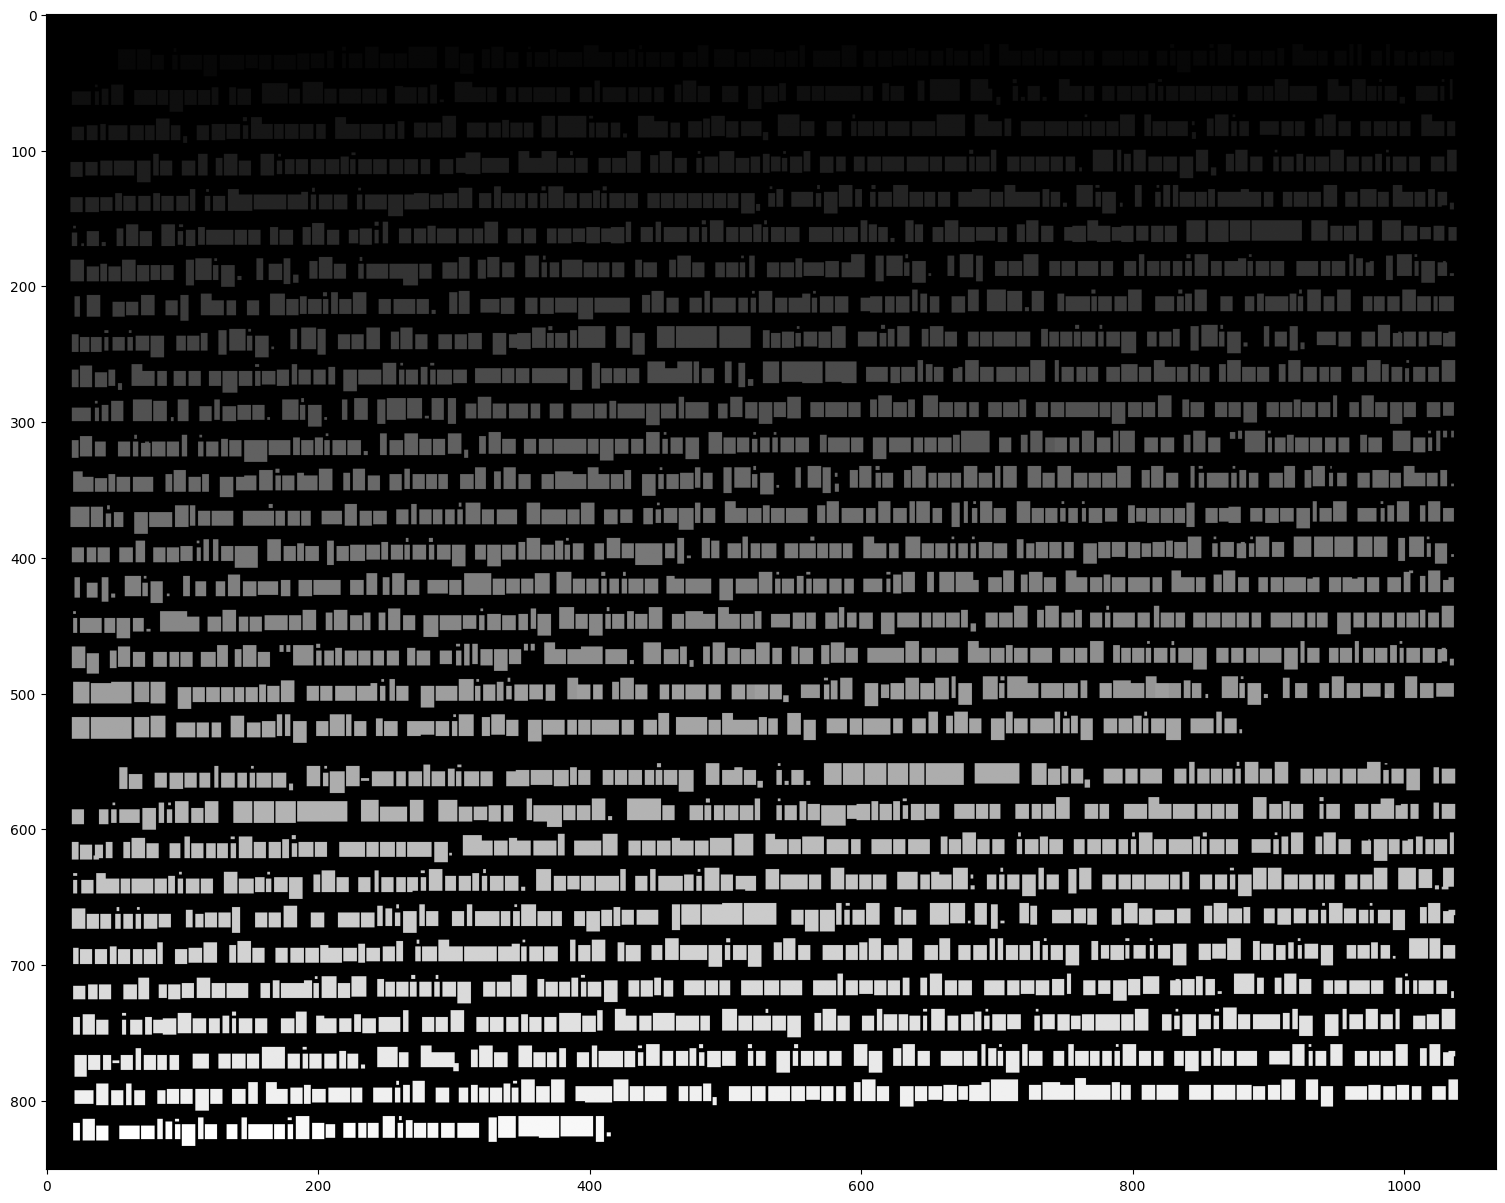

In [12]:
label_to_line = [[]for _ in range(len(maxima))]
maxima = np.array(maxima)
plt.figure(figsize=(20,15))
im_lines = np.zeros(im.shape)
for obj in object_properties:
    closest_line = np.abs(obj['centroid'][0]-maxima).argmin() 
    label_to_line[closest_line].append(obj) #add the label of the object to the list of labels corresponding to the closest line
    #print(obj['centroid'][0])
    #print(abs(obj['centroid'][0]-maxima))
    #print(closest_line)
    im_lines[obj.bbox[0]:obj.bbox[2], obj.bbox[1]:obj.bbox[3]] = closest_line+1 #color the object with the index of the closest line
plt.imshow(im_lines, cmap=plt.cm.gray)
plt.show()

In [15]:
ordered_labels = [[]for _ in range(len(maxima))]
for i, line_object in enumerate(label_to_line):
    x_pos=np.array([obj['centroid'][1] for obj in line_object]) #position horizontale des objets de la ligne
    x_order = x_pos.argsort() #order of the objects in the line according to their horizontal position
    print(x_order)

    for x in x_order:
        ordered_labels[i].append(line_object[x]) #add the object to the ordered list of objects for the line
    


[ 25  26  95  20  96  97  98  99 100 101 102 103  88  89  32  14  90  91
  15  92  93  16  17  94  27  18  72  19  73  74  28  75  76   9  77  78
  29  79  10  80  81  82  11  30  83  31  84  33  12  34  35  13  36  37
  38  21  39  40  22  41  42   0   1  43  44  23  45  46  47  48  49  50
  51  52   2  53  54  55   3  56   4  57  58  59  24   5  60  61  62  63
   6   7  64  65   8  66  67 104  85  68 105  86  69  70 106  87  71]
[89 20 90 75 21 83 84 85 86 87 88 60 61 76 16 77 14 78 79 80 81 24 62 63
 22 95 15 64 65 66 67 68 69 70 11 71 72 73 74 23 12 25 26 27 28 17 29 30
 31 32 33 18 34 13  0  1 82 91  2 35 92 36 93  3 37 38 39 40 41 19  4 42
 43 44 45 46 47 48 49  5 50  6 51 52  7 53 54  8 55 94 56 57 58 59  9 10]
[92 85 73 86 87 88 20 89 96 90 74 75 17 91 18 76 77 78 79 80 19 81 82 83
 84 26 63 64 11 65 66 25 67 68 12 13 14 69 70 71 95 15 27 72 28 21 16 29
 30 93  0 31 32 33  1 34 35 36 37 38  2  3 39 22 40 41 42  4 43 44 45  5
  6 46 47 48 94 23  7 49  8 50 51 52 53 24  9 54 55 5

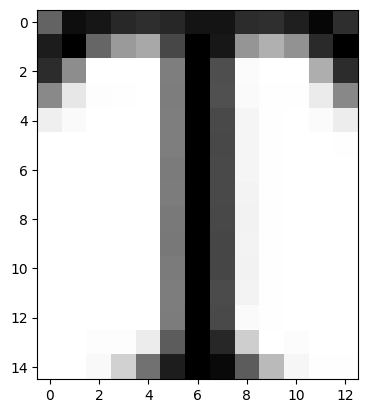

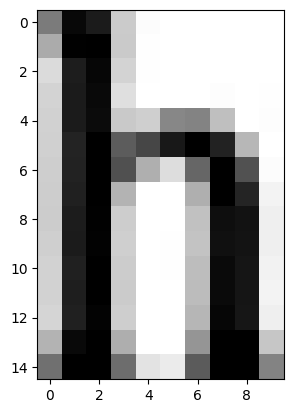

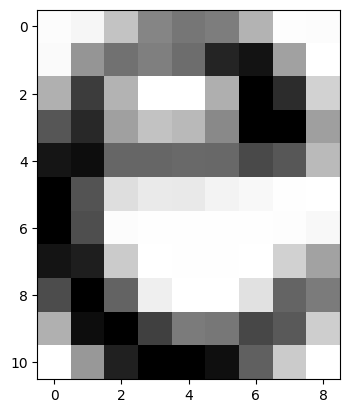

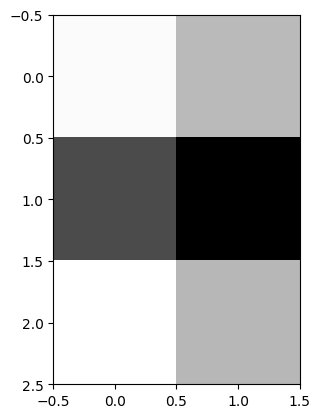

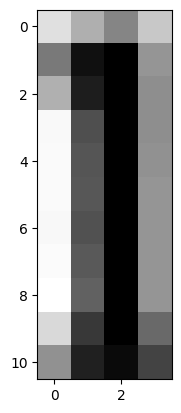

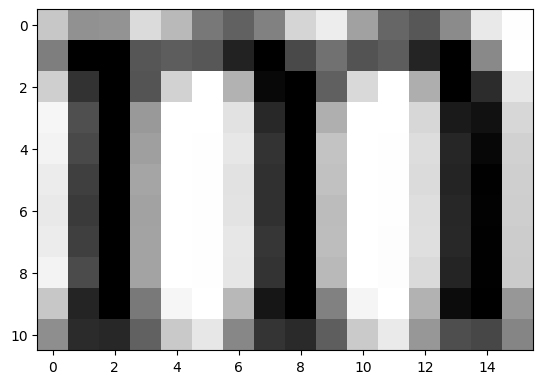

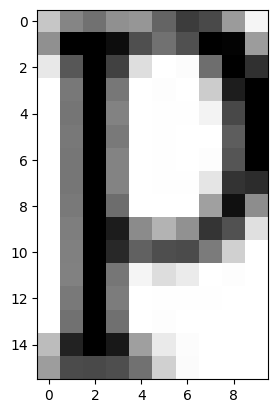

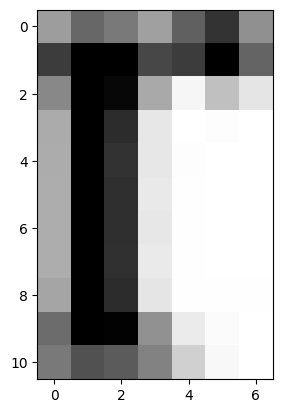

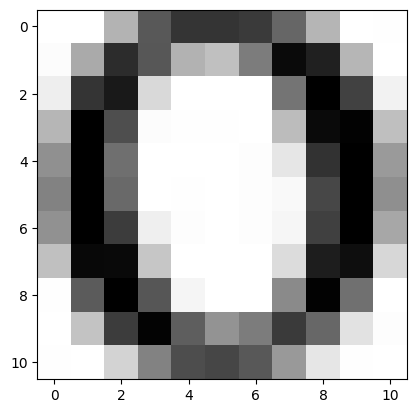

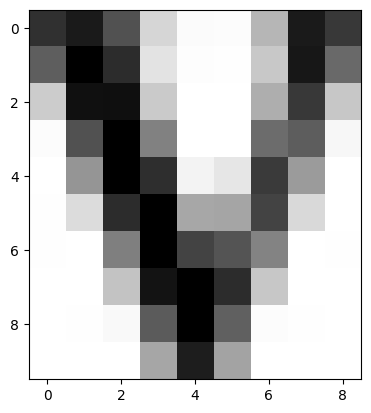

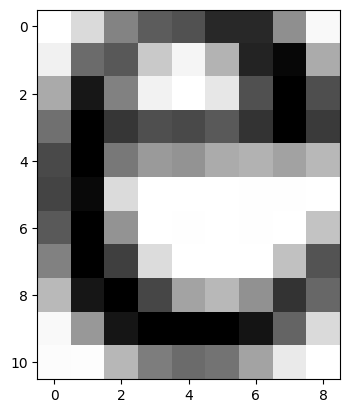

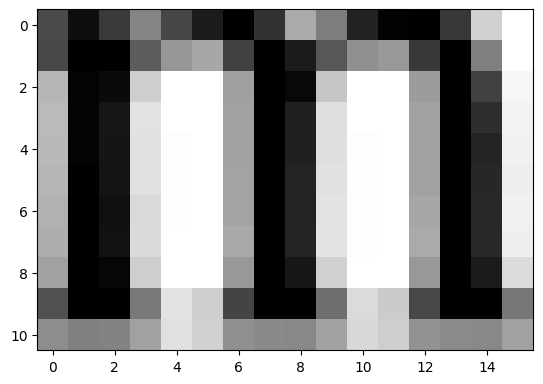

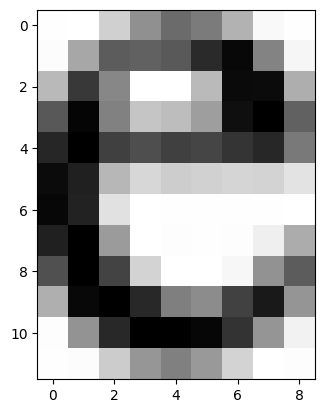

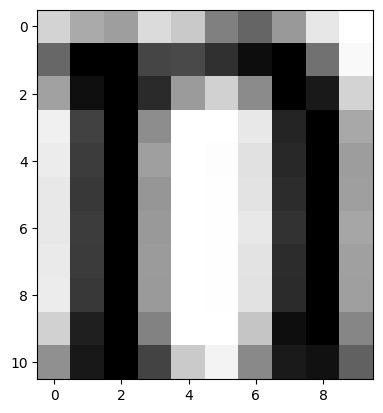

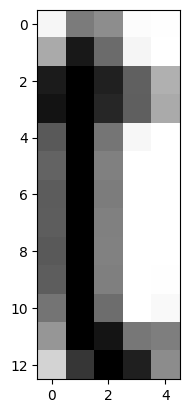

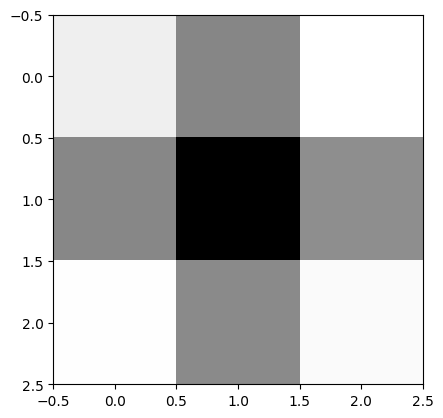

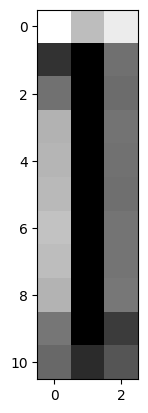

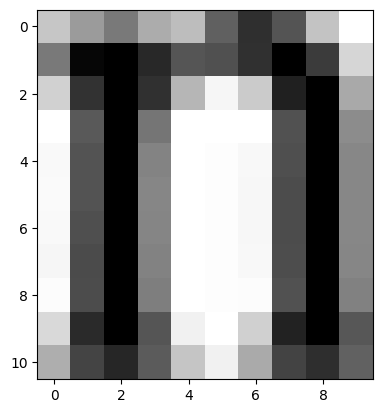

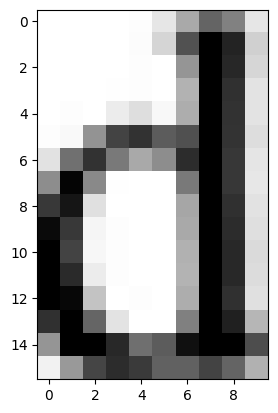

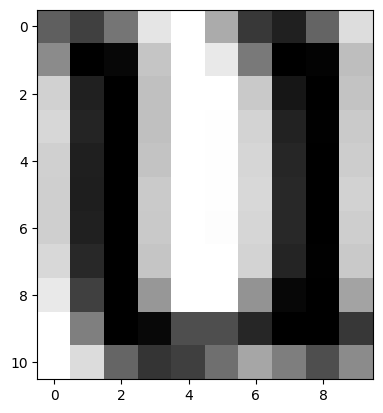

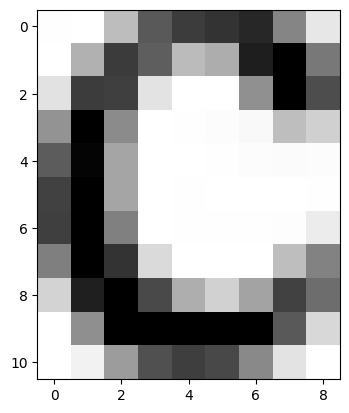

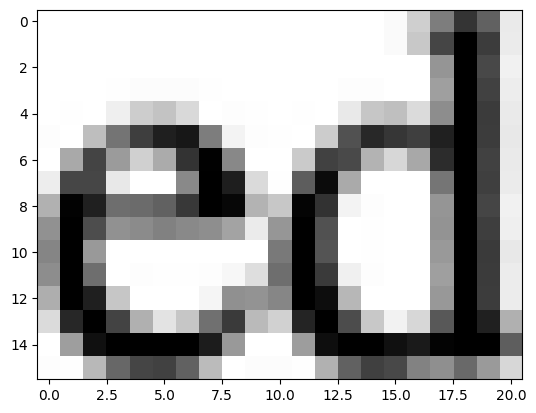

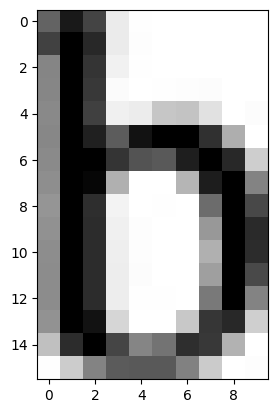

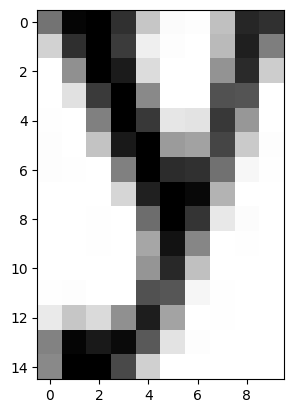

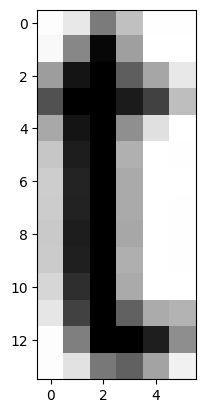

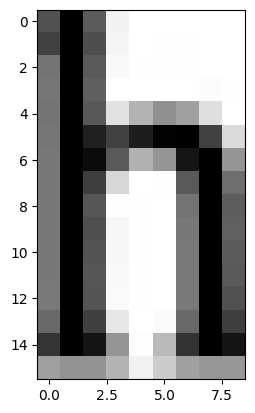

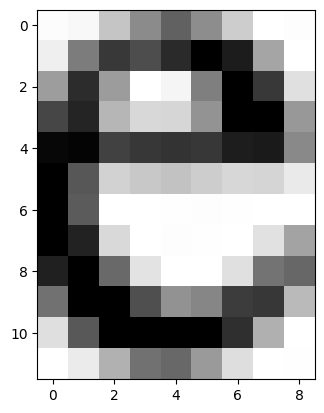

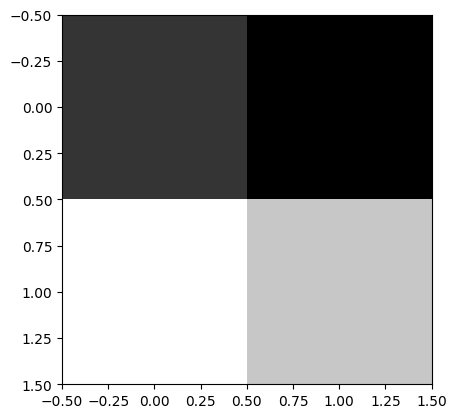

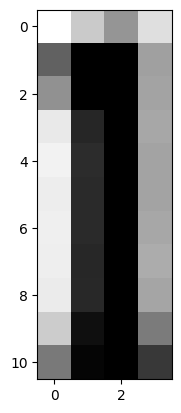

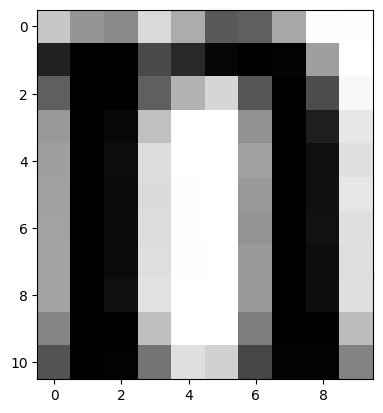

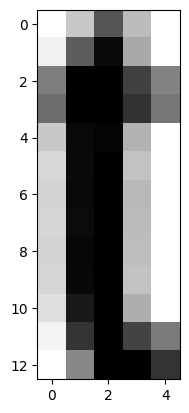

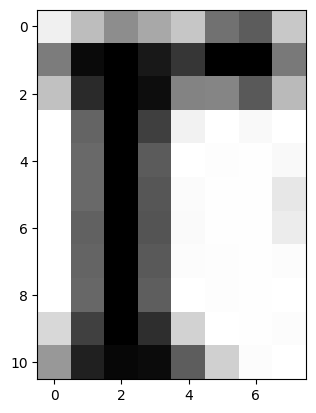

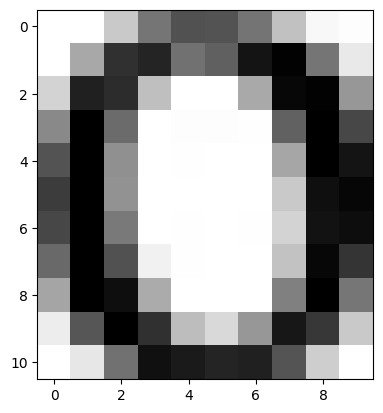

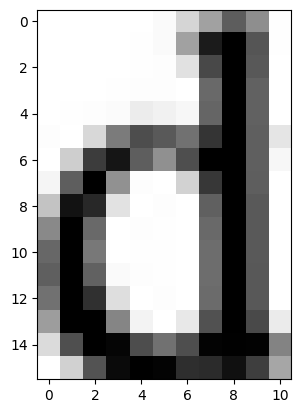

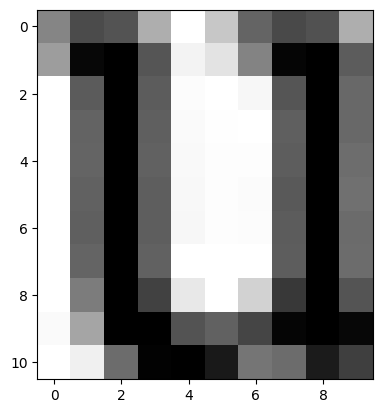

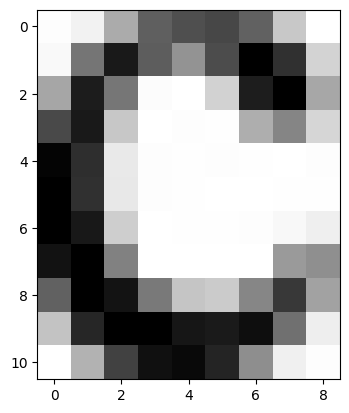

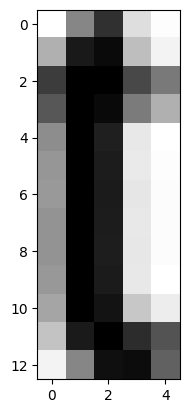

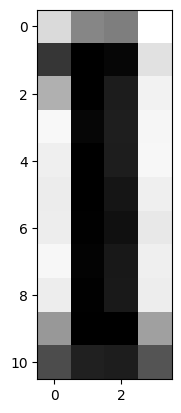

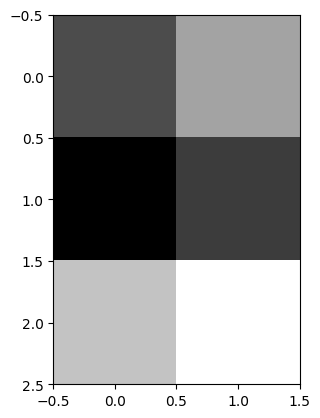

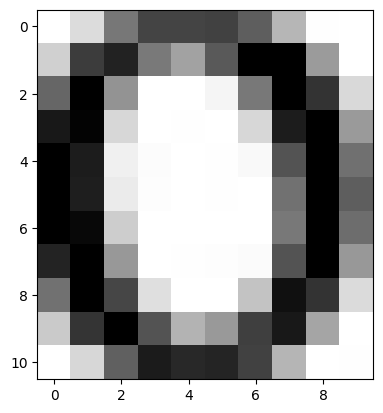

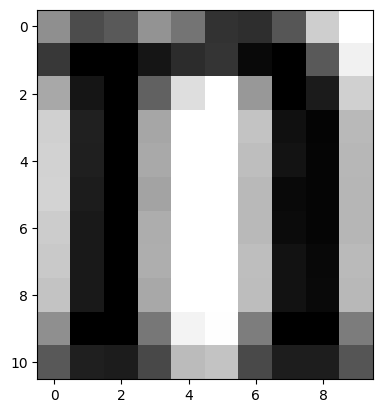

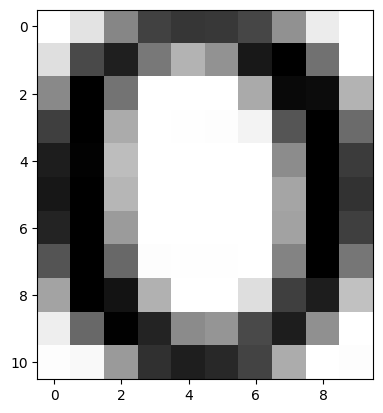

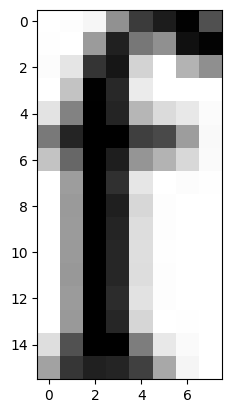

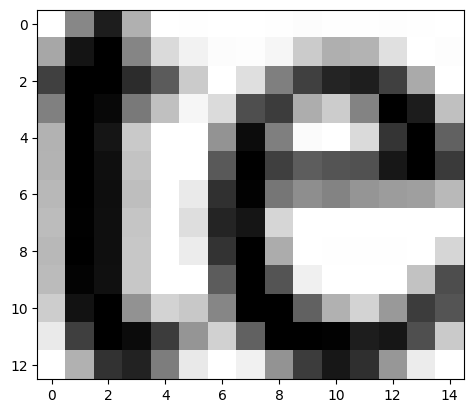

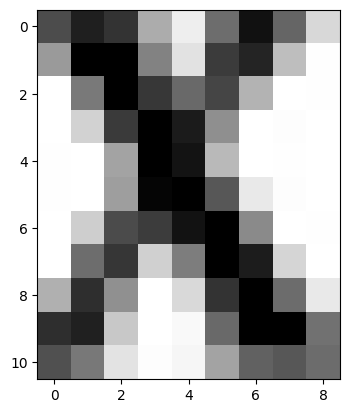

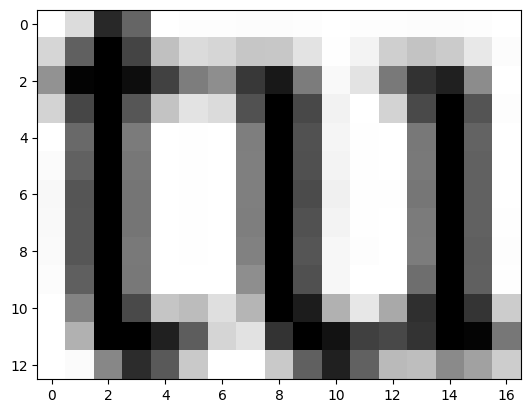

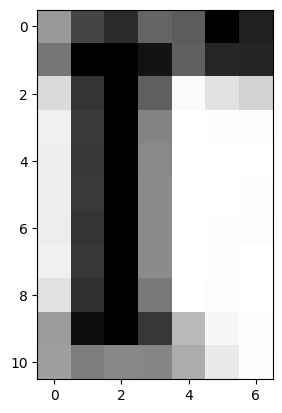

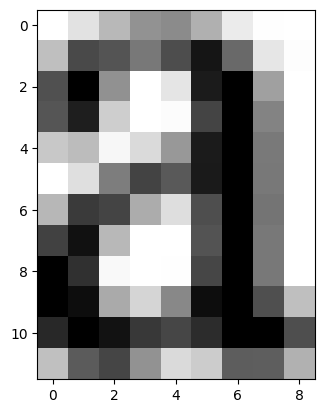

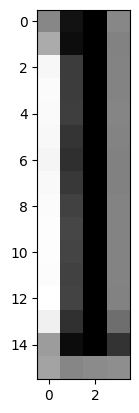

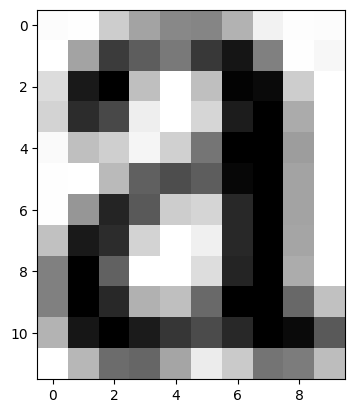

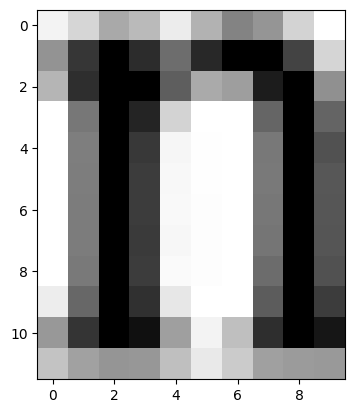

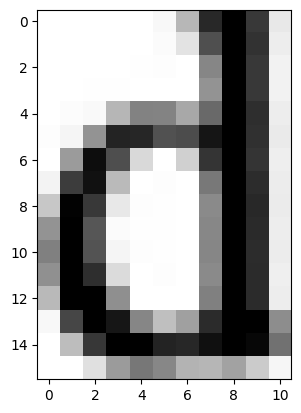

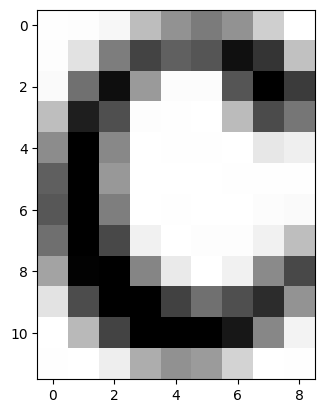

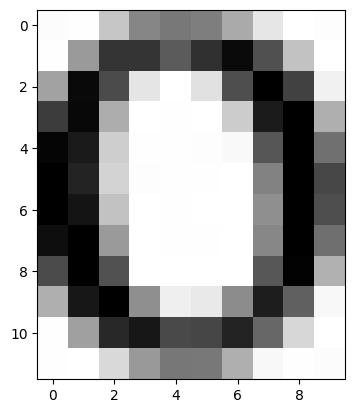

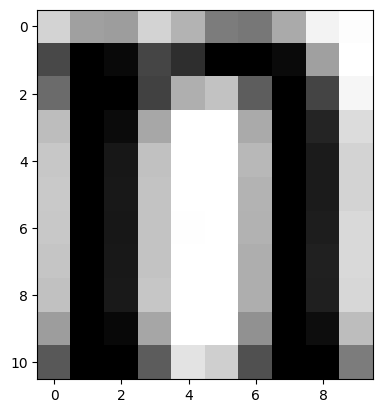

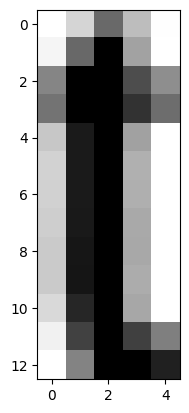

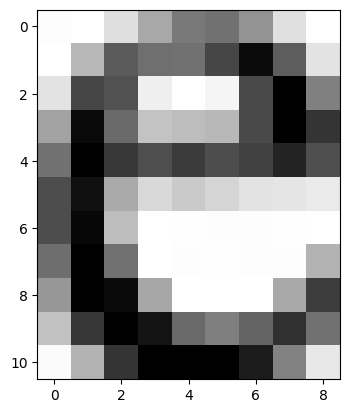

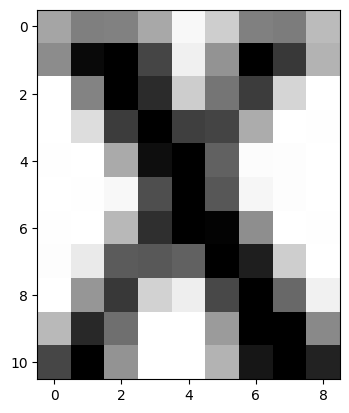

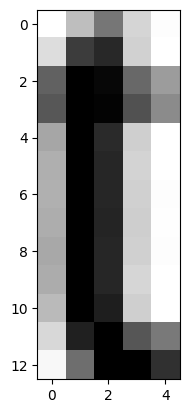

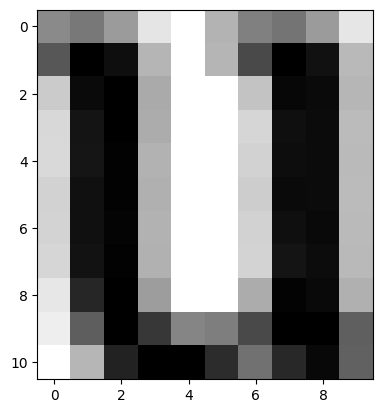

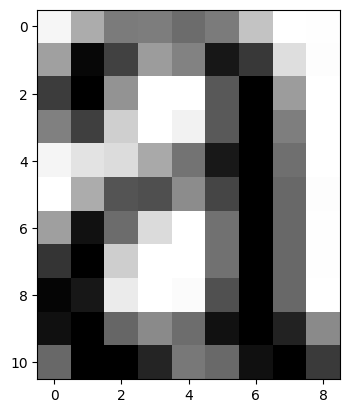

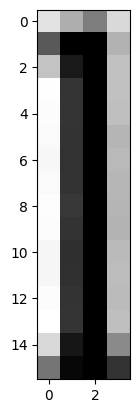

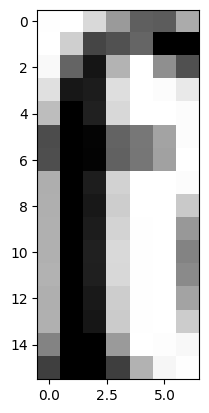

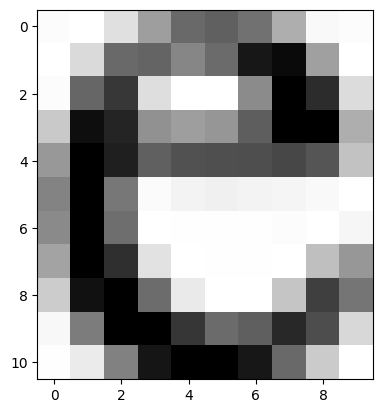

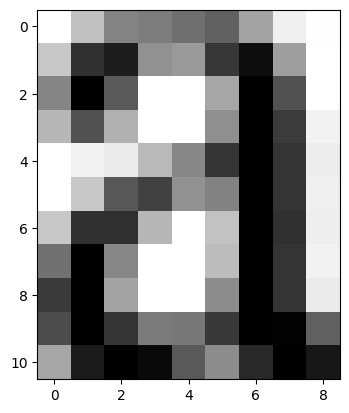

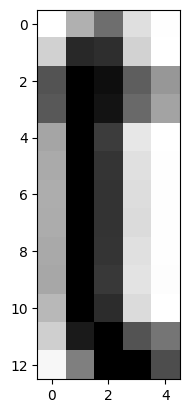

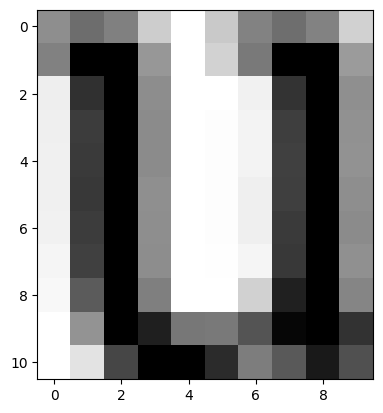

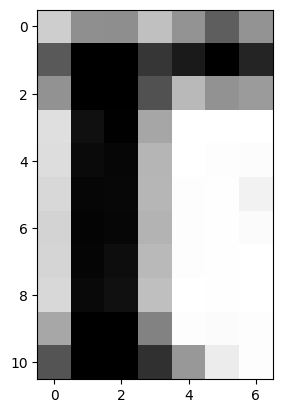

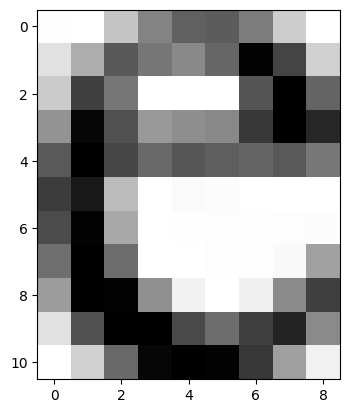

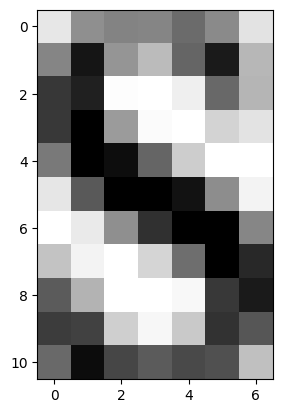

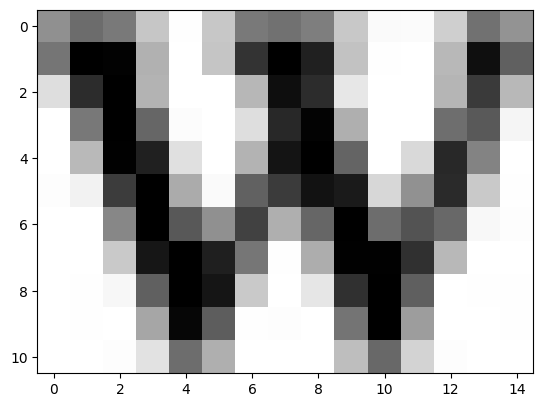

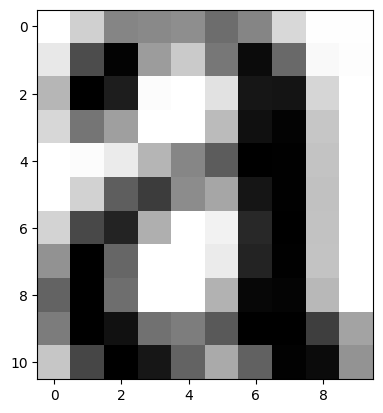

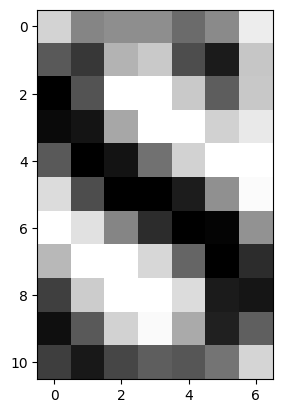

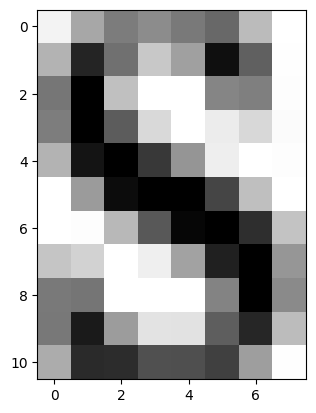

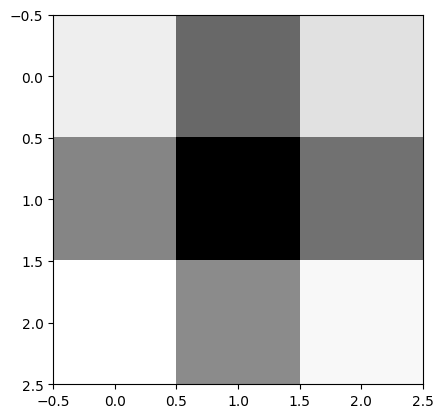

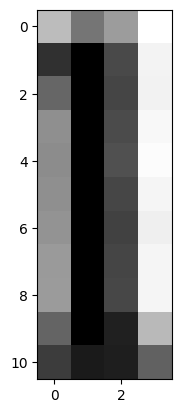

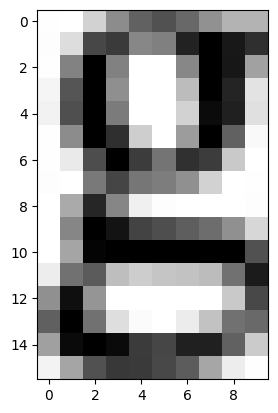

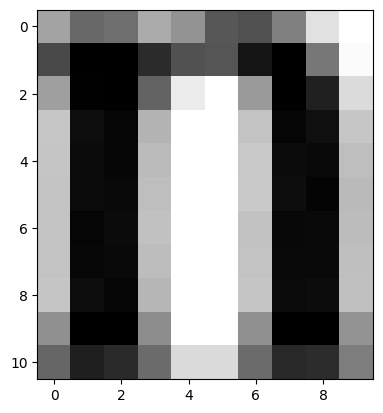

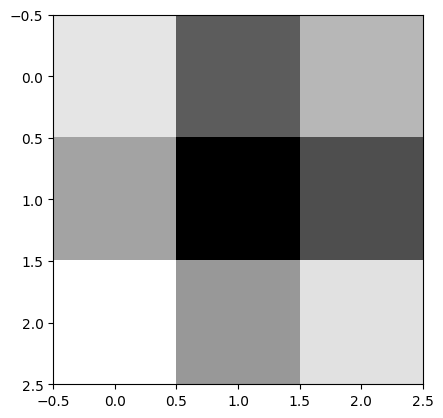

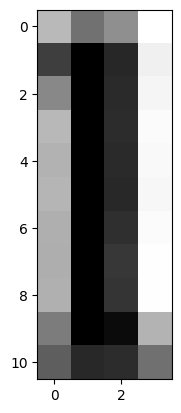

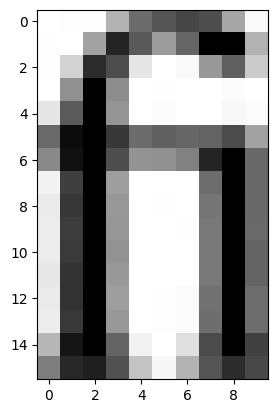

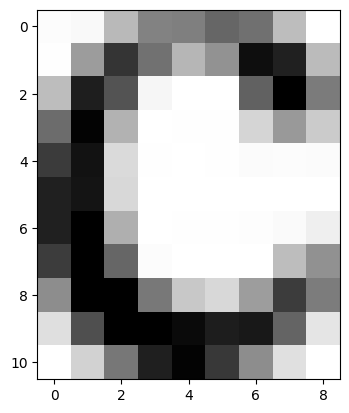

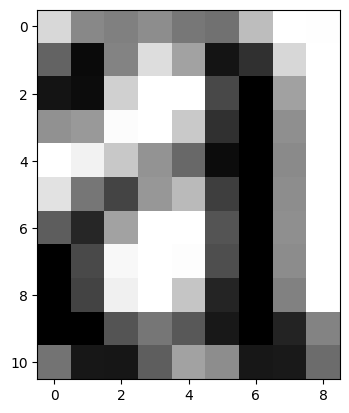

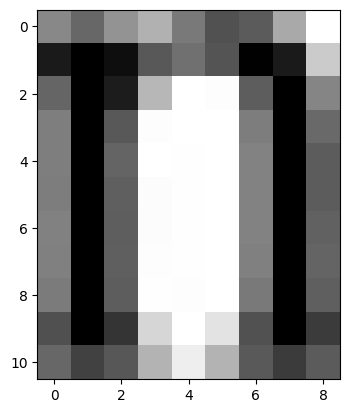

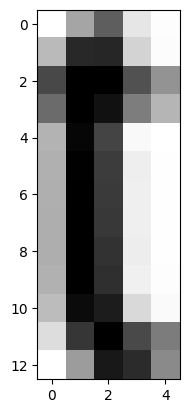

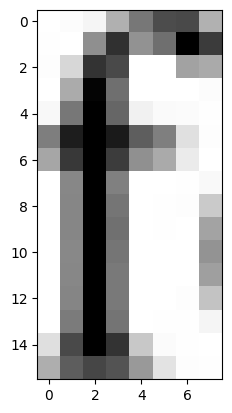

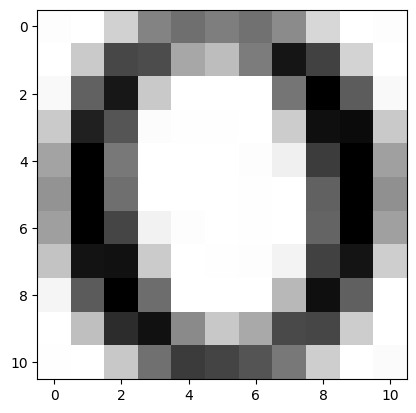

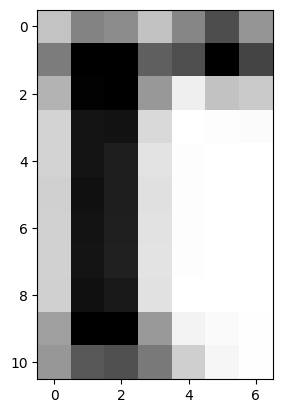

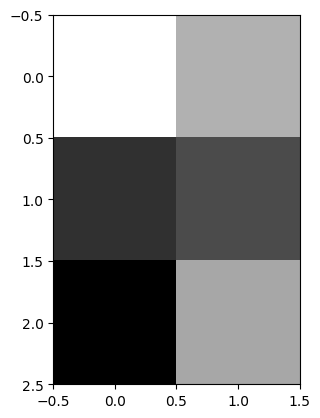

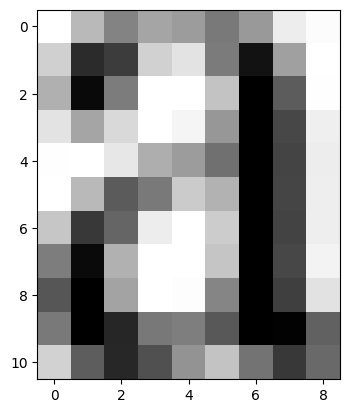

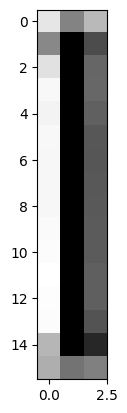

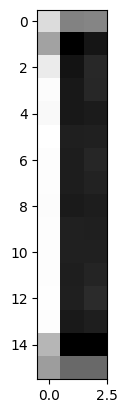

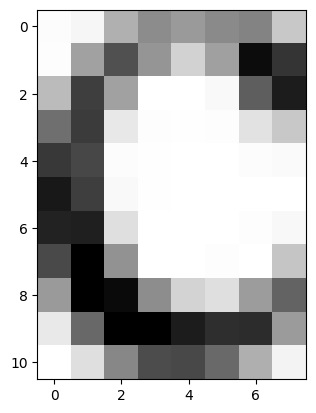

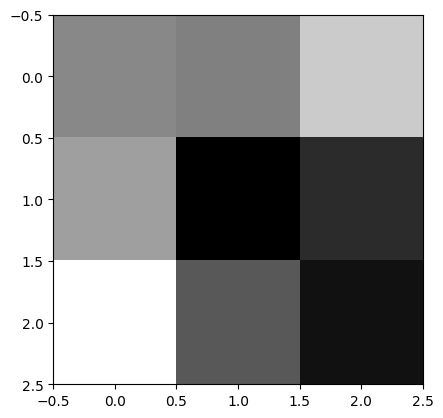

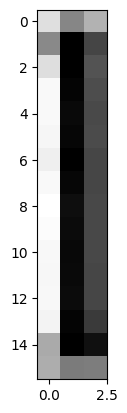

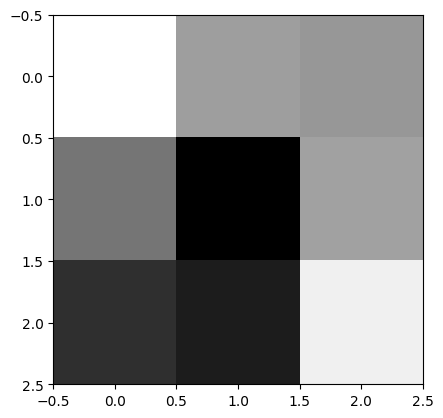

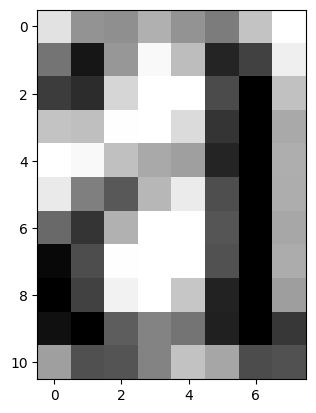

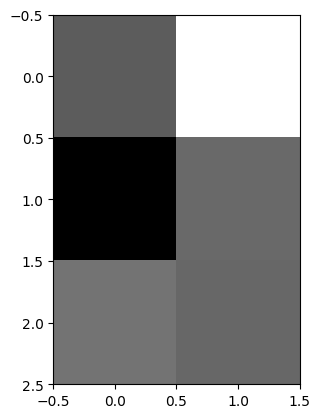

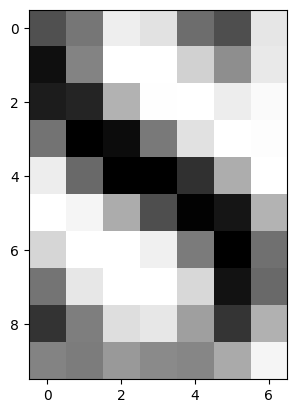

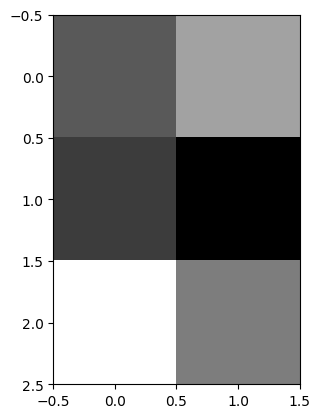

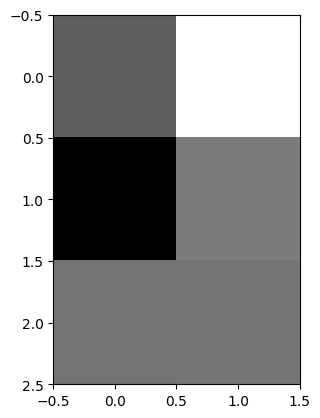

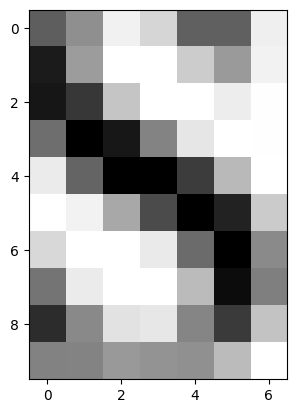

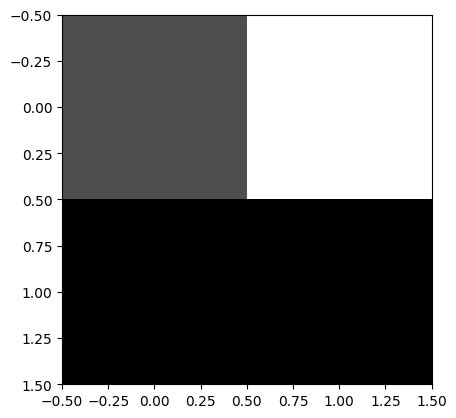

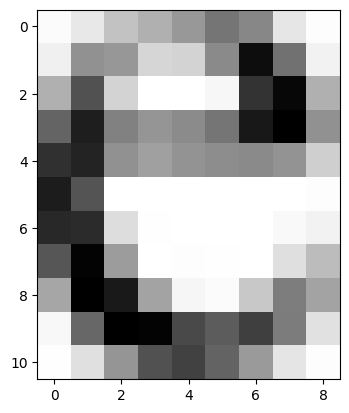

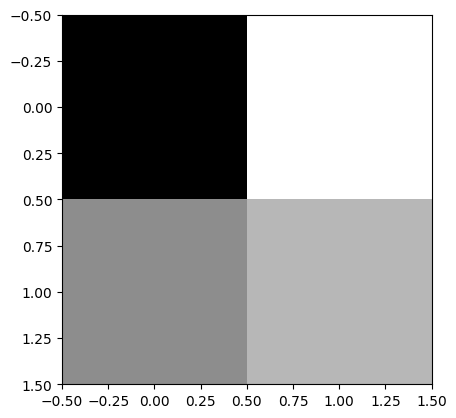

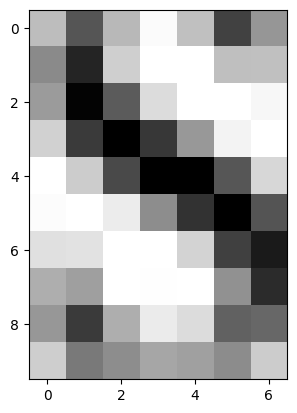

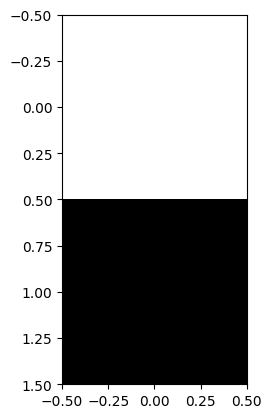

In [17]:
for obj in ordered_labels[0]:
    plt.figure()
    plt.imshow(im[obj.bbox[0]:obj.bbox[2], obj.bbox[1]:obj.bbox[3]], cmap=plt.cm.gray)
    plt.show()

## Expert System classification

* Using the features available with the [regionprops](http://scikit-image.org/docs/dev/api/skimage.measure.html#skimage.measure.regionprops) method of scikit-image, propose a method to automatically recognize some letters.

if we use the euler number defined as N_obj - N_holes, in our case the N_obj=0 so we have 1-N_holes which is equal to zero for letters surch as "a", "b","p",... with one hole. Euler number is = to 1 pour letters sucha as "c","t","j",... and -1 for 'B','g'.
First rule may be : 
if euler number = -1


    - if the centroid of the letter is below the center of the line by a large enough margin : it's a 'g'
    - if the bouding box is not too large : 'B'
    - else : it is a double letter thate should be removed 

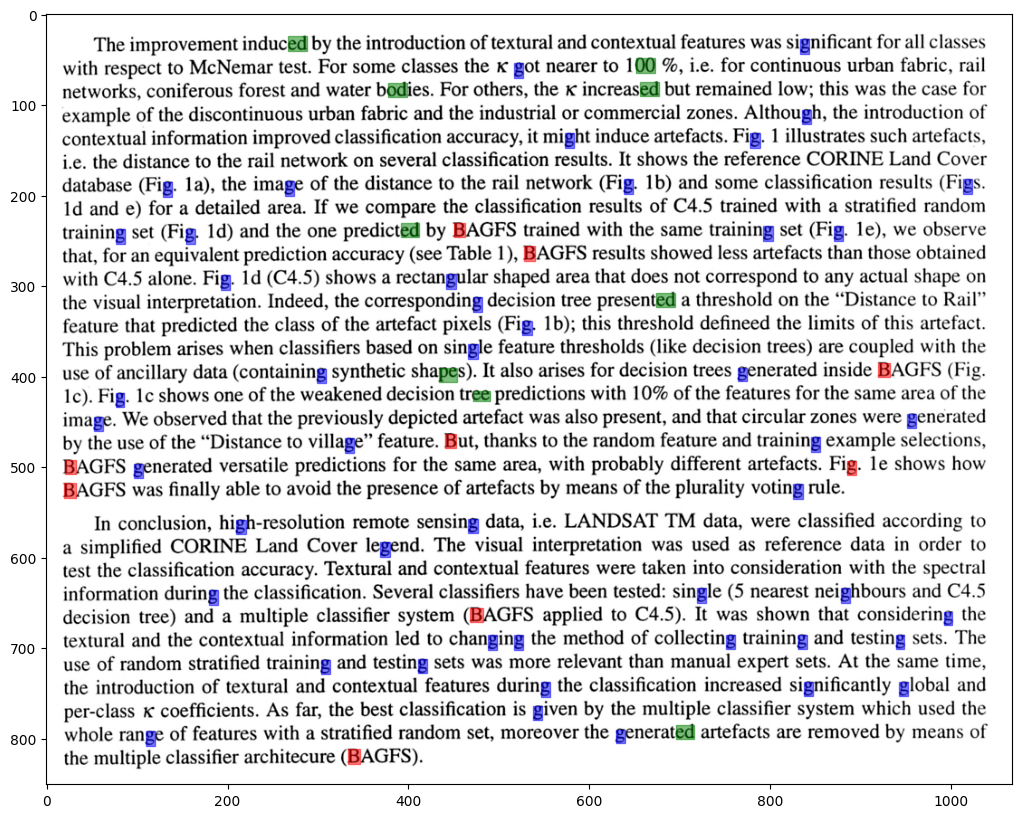

In [21]:
from matplotlib.patches import Rectangle

plt.figure(figsize=(15,10))
plt.imshow(im, cmap='gray')

for idline, line in enumerate(ordered_labels):
    highest_centroid = 99999
    t_candidate = None
    for letter in line:
        bbox = letter.bbox
        

        if letter.euler_number == -1:
            # plutôt g
            if letter.centroid[0] > maxima[idline] + 2:
                plt.gca().add_patch(
                    Rectangle((bbox[1], bbox[0]), bbox[3]-bbox[1], bbox[2]-bbox[0], alpha=0.5, color='b'))
            # plutôt B
            elif bbox[3]-bbox[1] < 15:
                plt.gca().add_patch(
                    Rectangle((bbox[1], bbox[0]), bbox[3]-bbox[1], bbox[2]-bbox[0], alpha=0.5, color='r'))
            # double lettre
            else:

                plt.gca().add_patch(
                    Rectangle((bbox[1], bbox[0]), bbox[3]-bbox[1], bbox[2]-bbox[0], alpha=0.5, color='g'))
        if letter.euler_number == 1: 
             if letter.centroid[0] < highest_centroid:
                highest_centroid = letter.centroid[0]
                t_candidate = letter
    

            
            
plt.show()

## Full OCR pipeline

Using all the previous exercices, create a method that takes as input a text image, and outputs the recognized text.

In [ ]:
def OCR(im):
    text = ''
    
    return text

print(OCR(im))